In [1]:
import yaml
from ultralytics import YOLO
import torch
import os
import cv2
import matplotlib.pyplot as plt

In [2]:
dataset_path = "/home/jony/Downloads/mevalar_dataset"

yaml_content = {
    'path': dataset_path,
    'train': 'train/images',
    'val': 'train/images', 
    'nc': 1,
    'names': ['Counting-Fruits']
}

In [3]:
yaml_file_path = "/home/jony/my_code/dataset_config.yaml"
with open(yaml_file_path, 'w') as f:
    yaml.dump(yaml_content, f)

model = YOLO("yolov8n.pt")
device = "cuda" if torch.cuda.is_available() else "cpu"

model.train(
    data="/home/jony/my_code/dataset_config.yaml",
    epochs=200,          
    batch=16,            
    imgsz=640,
    device=device,
    patience=20,     
    lr0=0.01,         
    mosaic=1.0, 
    cache=False
)

Ultralytics 8.4.56 🚀 Python-3.14.4 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 5773MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/jony/my_code/dataset_config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cf7ccbde350>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

🤖 NATIJA: Rasmdan jami 91 ta meva topildi!


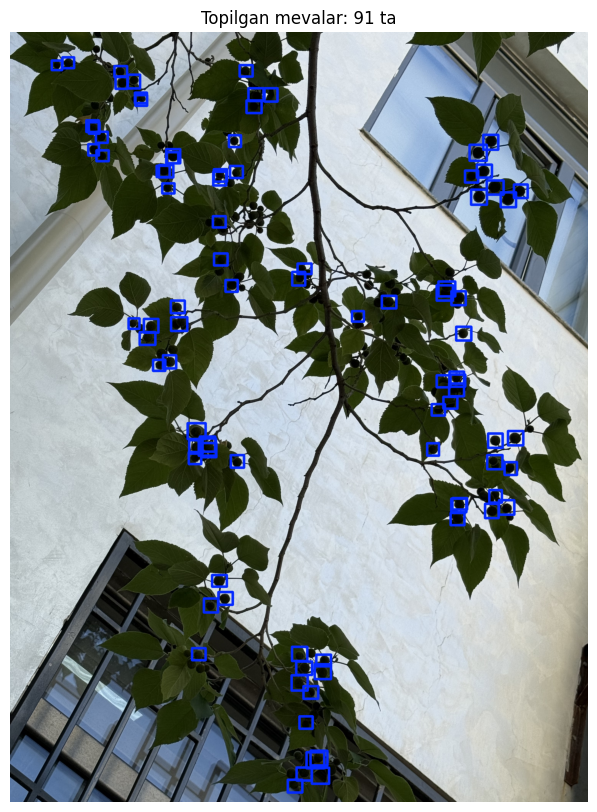

In [4]:
%matplotlib inline
model_path = "/home/jony/my_code/runs/detect/train-10/weights/best.pt"
my_model = YOLO(model_path)

image_path = "/home/jony/Pictures/Telegram Rasmlar/test_rrr.JPG"
results = my_model(image_path, verbose=False)
result = results[0]
mevalar_soni = len(result.boxes)

print("=" * 45)
print(f"🤖 NATIJA: Rasmdan jami {mevalar_soni} ta meva topildi!")
print("=" * 45)

annotated_img = result.plot(labels=False, conf=False)
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.title(f"Topilgan mevalar: {mevalar_soni} ta")
plt.axis('off')
plt.show()

🤖 NATIJA: Rasmdan jami 132 ta meva topildi!


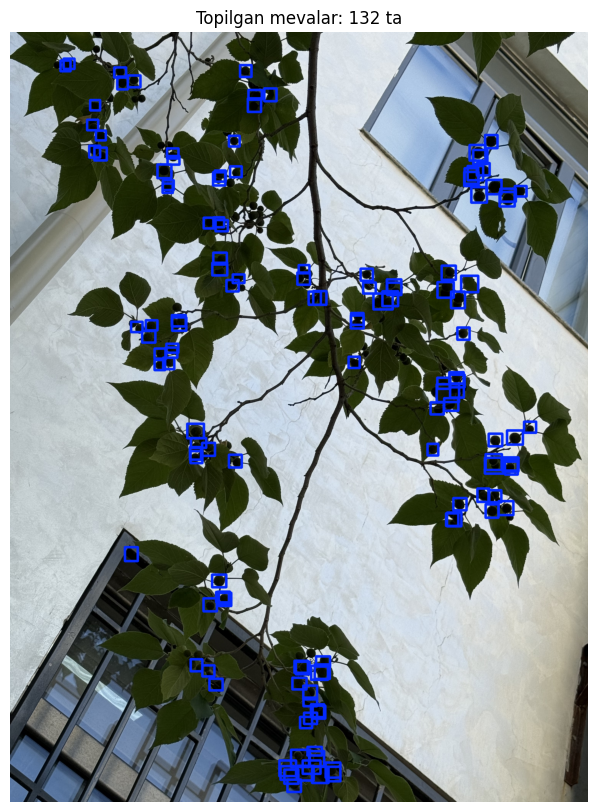

In [5]:
%matplotlib inline
model_path = "/home/jony/Downloads/best.pt"
my_model = YOLO(model_path)

image_path = "/home/jony/Pictures/Telegram Rasmlar/test_rrr.JPG"
results = my_model(image_path, verbose=False)
result = results[0]
mevalar_soni = len(result.boxes)

print("=" * 45)
print(f"🤖 NATIJA: Rasmdan jami {mevalar_soni} ta meva topildi!")
print("=" * 45)

annotated_img = result.plot(labels=False, conf=False)
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.title(f"Topilgan mevalar: {mevalar_soni} ta")
plt.axis('off')
plt.show()